In [1]:
# 패키지 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import plot_importance
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")
matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc("axes", unicode_minus = False)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

def eval_class_model(y_test, y_pred):
    confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)
    
    print('오차행렬:\n', confusion, '\n')
    print('정확도: {:.4f}'.format(accuracy))
    print('정밀도: {:.4f}'.format(precision))
    print('재현율: {:.4f}'.format(recall))
    print('F1    : {:.4f}'.format(F1))
    print('AUC   : {:.4f}'.format(AUC))

In [2]:
# 데이터 불러오기
df_raw = pd.read_csv("통신고객이탈.csv")

# 결측치 확인 및 처리
df_raw.isnull().sum()
    # 결측치를 인식하지 못하여 처리
df_raw['USAGE_BAND'].replace("None", np.nan, inplace=True)
df_raw['USAGE_BAND'].fillna(df_raw['USAGE_BAND'].mode()[0], inplace=True)
    # 종속변수 처리
df_raw['CHURN'].replace({'Churned': 1, 'Active': 0}, inplace = True)
df_raw.drop(["CUSTOMER_ID"], axis =1, inplace = True)
    # 문자형 변수 처리
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()
    # 데이터 분리
df_raw_x = df_raw_dummy.drop("CHURN", axis= 1 , inplace= False)
df_raw_y = df_raw_dummy["CHURN"]

### 그래디언트 부스팅

분할 전 설명변수 데이터 : (930, 32)
분할 후 설명변수 데이터 :Train (651, 32)   Test (279, 32)
Accuracy on training set: 0.965
Accuracy on test set: 0.896

best parameter: 
{'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.5}

best score: 
0.891
Train Accuracy: 1.000
Test Accuracy: 0.896

Test Confusion matrix: 
[[221  14]
 [ 15  29]]
              precision    recall  f1-score   support

           0      0.936     0.940     0.938       235
           1      0.674     0.659     0.667        44

    accuracy                          0.896       279
   macro avg      0.805     0.800     0.803       279
weighted avg      0.895     0.896     0.896       279



Text(0, 0.5, '설명변수')

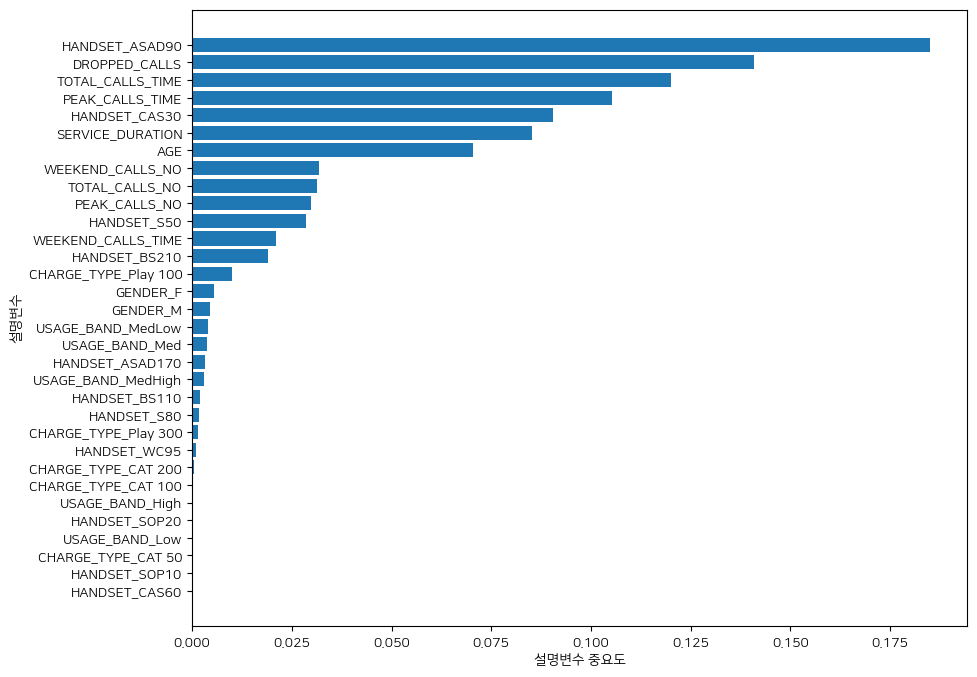

In [3]:
# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size= 0.3, random_state= 1234)
print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)
print("===========================================================")

# 모델 생성
gb_uncust = GradientBoostingClassifier(random_state=1234)
gb_uncust.fit(df_train_x, df_train_y)

print("Accuracy on training set: {:.3f}".format(gb_uncust.score (df_train_x, df_train_y)))
print("Accuracy on test set: {:.3f}".format(gb_uncust.score (df_test_x, df_test_y)))
print("===========================================================")

# 랜덤서치를 통한 하이퍼파라미터 조정
estimator = GradientBoostingClassifier(n_estimators=100, random_state=1234)

    # 구하고자 하는 parameter와 범위
para_lr = [lr * 0.1 for lr in range(1, 10)]
para_depth = [depth for depth in range(1, 10)]
para_leaf = [n_leaf for n_leaf in range(1, 50)]
param_grid = {"learning_rate": para_lr,
              "max_depth": para_depth,
              "min_samples_leaf": para_leaf}

    # 정확도가 높은 최적 parameter 찾기
grid_gb = RandomizedSearchCV(estimator, param_distributions= param_grid, scoring="accuracy",n_iter = 10, n_jobs = -1)
grid_gb.fit(df_train_x, df_train_y)
print("\nbest parameter: \n{}".format(grid_gb.best_params_))
print("\nbest score: \n{}".format(grid_gb.best_score_.round(3)))
print("===========================================================")

# 최종 모델
gb_final = GradientBoostingClassifier(n_estimators=100, random_state=1234,
                                      **grid_gb.best_params_)
gb_final.fit(df_train_x, df_train_y)
y_pred = gb_final.predict(df_test_x)

    # train 모델 정확도
print("Train Accuracy: {:.3f}".format(gb_final.score(df_train_x, df_train_y)))
    # test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(gb_final.score(df_test_x, df_test_y)))
    # confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
    # 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))
print("===========================================================")

# 변수명
v_feature_name = df_train_x.columns
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance ["Feature"] = v_feature_name
df_importance ["Importance"] = gb_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance .sort_values("Importance", ascending=False, inplace = True)
df_importance .round(3)

# 설명변수 중요도 그래프
fig, ax = plt.subplots(figsize=(10, 8))

df_importance .sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance ["Importance"])
plt.yticks(coordinates, df_importance ["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

테스트의 정확도는 0.896으로 학습 데이터가 1.000이라 과적합의 위험이 있었지만, 잘 예측하였다.<br>
하이퍼파라미터의 최적 조건은 max_depth: 5, learning_rate: 0.5가 나왔다.<br>
이탈 고객('1' 클래스)의 F1-점수는 0.667으로 준수한 성능을 보였다.<br>
핵심 변수로는 HANDSET_ASAD90와 TOTAL_CALLS_TIME이 모델 예측에 가장 중요한 영향을 미쳤다.<br>
하지만 과적합 해소와 소수 클래스 예측 능력 향상을 위해 추가적인 정규화 및 튜닝이 필요하다.<br>

### XGBOOST

분할 전 설명변수 데이터 : (930, 32)
분할 후 설명변수 데이터 :Train (651, 32)   Test (279, 32)
Accuracy on training set: 1.000
Accuracy on test set: 0.889

best parameter: 
{'max_depth': 6, 'learning_rate': 0.1}

best score: 
0.886
Train Accuracy: 1.000
Test Accuracy: 0.882

Test Confusion matrix: 
[[220  15]
 [ 18  26]]
              precision    recall  f1-score   support

           0      0.924     0.936     0.930       235
           1      0.634     0.591     0.612        44

    accuracy                          0.882       279
   macro avg      0.779     0.764     0.771       279
weighted avg      0.879     0.882     0.880       279



Text(0, 0.5, '설명변수')

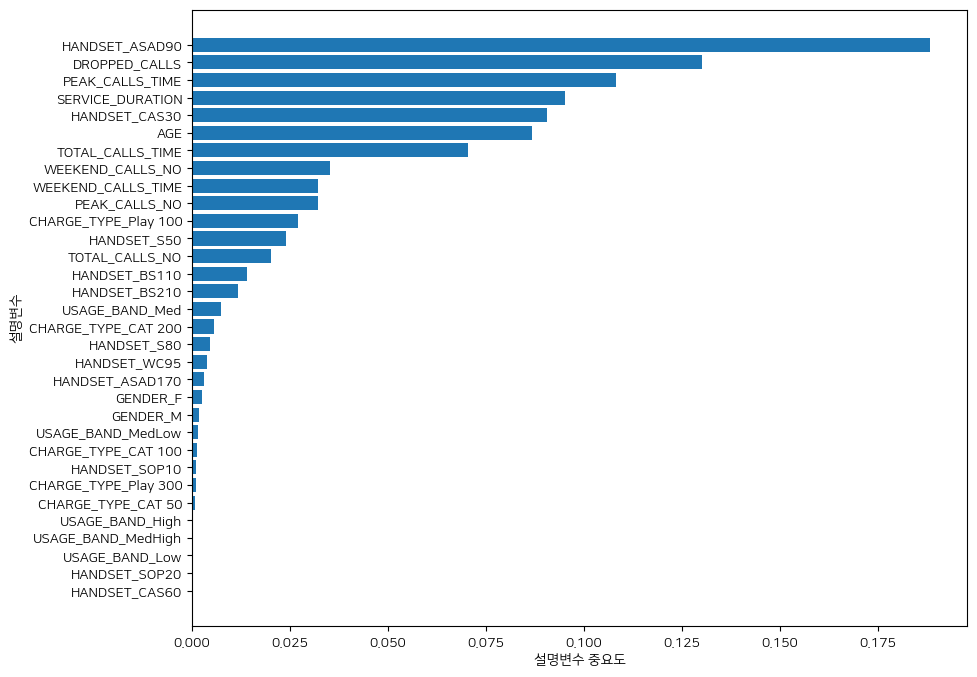

In [4]:
# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size= 0.3, random_state= 1234)
print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)
print("===========================================================")

# 모델 생성
xgboost_uncust = XGBClassifier(random_state=1234)
xgboost_uncust.fit(df_train_x, df_train_y)

print("Accuracy on training set: {:.3f}".format(xgboost_uncust.score (df_train_x, df_train_y)))
print("Accuracy on test set: {:.3f}".format(xgboost_uncust.score (df_test_x, df_test_y)))
print("===========================================================")

# 랜덤서치를 통한 하이퍼파라미터 조정
estimator = XGBClassifier(n_estimators=100, random_state=1234)

    # 구하고자 하는 parameter와 범위
para_lr = [lr * 0.1 for lr in range(1, 10)]
para_depth = [depth for depth in range(1, 10)]
param_grid = {"learning_rate": para_lr,
              "max_depth": para_depth}

    # 정확도가 높은 최적 parameter 찾기
grid_xg = RandomizedSearchCV(estimator, param_distributions= param_grid, scoring="accuracy",n_iter = 10, n_jobs = -1)
grid_xg.fit(df_train_x, df_train_y)
print("\nbest parameter: \n{}".format(grid_xg.best_params_))
print("\nbest score: \n{}".format(grid_xg.best_score_.round(3)))
print("===========================================================")

# 최종 모델
xg_final = GradientBoostingClassifier(n_estimators=100, random_state=1234,
                                      **grid_xg.best_params_)
xg_final.fit(df_train_x, df_train_y)
y_pred = xg_final.predict(df_test_x)

    # train 모델 정확도
print("Train Accuracy: {:.3f}".format(xg_final.score(df_train_x, df_train_y)))
    # test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(xg_final.score(df_test_x, df_test_y)))
    # confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
    # 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))
print("===========================================================")

# 변수명
v_feature_name = df_train_x.columns
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance ["Feature"] = v_feature_name
df_importance ["Importance"] = xg_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance .sort_values("Importance", ascending=False, inplace = True)
df_importance .round(3)

# 설명변수 중요도 그래프
fig, ax = plt.subplots(figsize=(10, 8))

df_importance .sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance ["Importance"])
plt.yticks(coordinates, df_importance ["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

테스트 정확도는 0.882로 상대적으로 낮았지만, 준수한 정확도를 보여주었다.<br>
하이퍼파라미터의 최적 조건은 max_depth: 6, learning_rate: 0.1로 나왔다.<br>
이탈 고객의 F1-점수는 0.771로 많이 개선된 모습을 보였다.<br>
핵심 변수는 HANDSET_ASAD90와 DROPPED_CALLS로 모델 예측에 가장 큰 영향을 미쳤다.<br>
따라서 사용량 낮은 그룹을 중심으로 하는 집중적인 이탈 방지 전략을 실행해야 한다.<br>

### SVM

In [5]:
# 데이터를 정규화해야하므로 다시 정제
# 데이터 불러오기
df_raw = pd.read_csv("통신고객이탈.csv")

# 결측치 확인 및 처리
df_raw.isnull().sum()
    # 결측치를 인식하지 못하여 처리
df_raw['USAGE_BAND'].replace("None", np.nan, inplace=True)
df_raw['USAGE_BAND'].fillna(df_raw['USAGE_BAND'].mode()[0], inplace=True)
    # 종속변수 처리
df_raw['CHURN'].replace({'Churned': 1, 'Active': 0}, inplace = True)
df_raw.drop(["CUSTOMER_ID"], axis =1, inplace = True)
    # 목표변수/설명변수 분리
df_raw_x = df_raw.drop("CHURN", axis = 1, inplace = False)
df_raw_y = df_raw["CHURN"] 
    # 연속형 변수 처리
df_raw_x_num = df_raw_x.select_dtypes(exclude = "object")
v_feature_names = df_raw_x_num.columns

scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_raw_x_num)
df_x_scaled = pd.DataFrame(df_x_scaled, columns=v_feature_names)
    # 범주형 변수 처리
df_raw_x_char = df_raw_x.select_dtypes(include = "object")
df_raw_x_char.head()

df_x_dummy = pd.get_dummies(df_raw_x_char)
df_x_dummy.head()
    # 데이터 결합
df_x_converted = df_x_scaled.join(df_x_dummy)
display(df_x_converted)

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,GENDER_F,...,HANDSET_S50,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,1,...,0,0,0,0,0,0,0,1,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,0,...,1,0,0,0,0,0,0,1,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,0,...,0,0,0,0,0,0,0,1,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,0,...,0,0,0,0,0,0,0,1,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,1,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,-0.946273,-1.193429,2.663042,-0.730750,-1.158696,0.691004,0.280989,-0.877769,-0.791564,0,...,0,0,1,0,0,0,0,1,0,0
926,2.105956,-1.195545,3.520007,-0.633572,-1.101652,-0.245052,-0.639911,0.042986,-0.750404,1,...,0,0,0,1,0,0,0,1,0,0
927,0.122007,0.748137,2.663042,-0.227191,-0.798967,0.566197,0.489288,0.999770,-0.040077,1,...,1,0,0,0,0,0,0,1,0,0
928,-0.488439,0.430773,3.234352,0.395633,-0.283239,-0.993897,-1.347031,1.051813,0.233042,1,...,1,0,0,0,0,0,0,1,0,0


In [6]:
# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x_converted, df_raw_y
                                    , test_size = 0.3, random_state = 1234)
print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))
print("===========================================================")

# 모델 생성
svm_uncust = SVC(random_state=1234)
svm_uncust.fit(df_train_x, df_train_y)

print("Accuracy on training set: {:.3f}".format(svm_uncust.score (df_train_x, df_train_y)))
print("Accuracy on test set: {:.3f}".format(svm_uncust.score (df_test_x, df_test_y)))
print("===========================================================")

# 랜덤서치를 통한 하이퍼파라미터 조정
estimator = SVC(random_state=1234)

    # 구하고자 하는 parameter와 범위
para_c = [0.1 * c for c in range(1, 100)]
para_gamma = [0.1 * gamma for gamma in range(1, 11)]
param_grid = {"C": para_c,
              "gamma": para_gamma}

    # 정확도가 높은 최적 parameter 찾기
grid_rf = RandomizedSearchCV(estimator, param_distributions= param_grid, scoring="accuracy",n_iter = 10, n_jobs = -1)
grid_rf.fit(df_train_x, df_train_y)
print("\nbest parameter: \n{}".format(grid_rf.best_params_))
print("\nbest score: \n{}".format(grid_rf.best_score_.round(3)))
print("===========================================================")

# 최종 모델
svm_final = SVC(random_state=1234, **grid_rf.best_params_)
svm_final.fit(df_train_x, df_train_y)
y_pred = svm_final.predict(df_test_x)

    # train 모델 정확도
print("Train Accuracy: {:.3f}".format(svm_final.score(df_train_x, df_train_y)))
    # test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(svm_final.score(df_test_x, df_test_y)))
    # confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
    # 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))

분할된 Train Data: (651, 32)
분할된 Test Data: (279, 32)
Accuracy on training set: 0.906
Accuracy on test set: 0.885

best parameter: 
{'gamma': 0.2, 'C': 8.9}

best score: 
0.833
Train Accuracy: 0.998
Test Accuracy: 0.867

Test Confusion matrix: 
[[224  11]
 [ 26  18]]
              precision    recall  f1-score   support

           0      0.896     0.953     0.924       235
           1      0.621     0.409     0.493        44

    accuracy                          0.867       279
   macro avg      0.758     0.681     0.708       279
weighted avg      0.853     0.867     0.856       279



최종 모델의 정확도는 0.867로 높은 정확도를 보여주었다.<br>
하이퍼파라미터의 최적 조건은 gamma값 0.2, 코스트값 8.9로, 큰 코스트와 커널 계수(gamma)를 보였다.<br>
이탈 고객의 F1-점수가 0.493으로 낮은 값을 보여주었지만, 랜덤그리드의 값에 따라 큰 변동을 보였다.<br>
이를 해소하기 위해 그리드서치를 통하여 gamma와 C 값을 낮춰 모델의 복잡도를 줄이고, 클래스 불균형 해결을 위한 추가 전처리가 필요해보인다.<br>

### Neural Network

In [7]:
# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x_converted, df_raw_y
                                    , test_size = 0.3, random_state = 1234)
print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))
print("===========================================================")

# 모델 생성
nn_uncust = MLPClassifier(random_state=1234)
nn_uncust.fit(df_train_x, df_train_y)

print("Accuracy on training set: {:.3f}".format(nn_uncust.score (df_train_x, df_train_y)))
print("Accuracy on test set: {:.3f}".format(nn_uncust.score (df_test_x, df_test_y)))
print("===========================================================")

# 랜덤서치를 통한 하이퍼파라미터 조정
estimator = MLPClassifier(random_state=1234, max_iter=3000)

    # 구하고자 하는 parameter와 범위
para_hidden = [5 * hidden for hidden in range(1, 21)]  # 은닉층 노드 
para_function = ['relu', 'logistic', 'tanh']
para_solver = ['lbfgs', 'sgd', 'adam']
para_batch = [32, 64, 128, 256]
para_lr = [0.001, 0.01, 0.1]

param_grid = {"hidden_layer_sizes":para_hidden,
            "activation": para_function,
              "solver": para_solver,
              "batch_size": para_batch,
              "learning_rate_init": para_lr}

    # 정확도가 높은 최적 parameter 찾기
grid_nn = RandomizedSearchCV(estimator, param_distributions= param_grid, scoring="accuracy",n_iter = 10, n_jobs = -1)
grid_nn.fit(df_train_x, df_train_y)
print("\nbest parameter: \n{}".format(grid_nn.best_params_))
print("\nbest score: \n{}".format(grid_nn.best_score_.round(3)))
print("===========================================================")

# 최종 모델
nn_final = MLPClassifier(random_state=1234, max_iter=3000, **grid_nn.best_params_)
nn_final.fit(df_train_x, df_train_y)
y_pred = nn_final.predict(df_test_x)

    # train 모델 정확도
print("Train Accuracy: {:.3f}".format(nn_final.score(df_train_x, df_train_y)))
    # test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(nn_final.score(df_test_x, df_test_y)))
    # confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
    # 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))

분할된 Train Data: (651, 32)
분할된 Test Data: (279, 32)
Accuracy on training set: 0.962
Accuracy on test set: 0.910

best parameter: 
{'solver': 'sgd', 'learning_rate_init': 0.001, 'hidden_layer_sizes': 70, 'batch_size': 64, 'activation': 'tanh'}

best score: 
0.892
Train Accuracy: 0.977
Test Accuracy: 0.896

Test Confusion matrix: 
[[221  14]
 [ 15  29]]
              precision    recall  f1-score   support

           0      0.936     0.940     0.938       235
           1      0.674     0.659     0.667        44

    accuracy                          0.896       279
   macro avg      0.805     0.800     0.803       279
weighted avg      0.895     0.896     0.896       279



 테스트 정확도는 0.896으로 전반적으로 우수한 분류 성능을 보였다.<br>
모델은 총 32개의 변수를 활용하여 651건의 학습 데이터와 279건의 테스트 데이터를 기반으로 학습되었다.<br>
최적 파라미터는 sgd방식, hidden_layer 70개, tanh함수로 나타났다.<br>
이탈 고객의 F1-점수는 0.667로 준수한 값을 나타났다.<br>
결론적으로, 다른 분석과 비교하였을 때, 인공신경망은 높은 이탈고객 재현율과 F1스코어를 보이며, 우수한 성능을 보여주었다.<br>
하지만 랜덤서치로 인하여 값이 미세하게 변화함에 따라 안정적인 값을 찾기 위해서는 그리드 서치가 필요할 것으로 판단된다.


### 모델 평가

의사결정나무
Confusion matrix: 
[[228   7]
 [ 17  27]]
              precision    recall  f1-score   support

           0      0.931     0.970     0.950       235
           1      0.794     0.614     0.692        44

    accuracy                          0.914       279
   macro avg      0.862     0.792     0.821       279
weighted avg      0.909     0.914     0.909       279



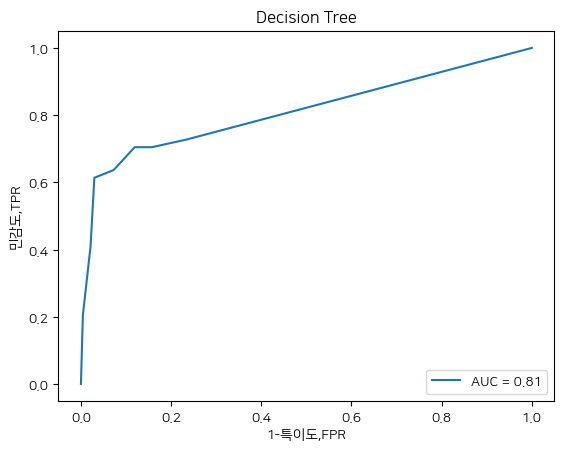

오분류율: 0.086
리프트(Lift): 5.035
랜덤포레스트
Confusion matrix: 
[[226   9]
 [ 17  27]]
              precision    recall  f1-score   support

           0      0.930     0.962     0.946       235
           1      0.750     0.614     0.675        44

    accuracy                          0.907       279
   macro avg      0.840     0.788     0.810       279
weighted avg      0.902     0.907     0.903       279



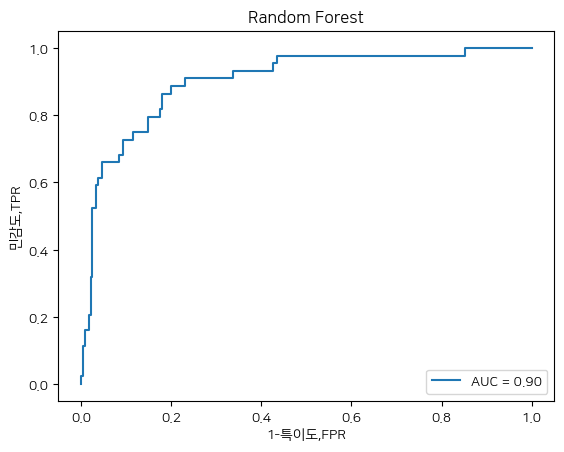

오분류율: 0.093
리프트(Lift): 4.756
그래디언트부스팅
Confusion matrix: 
[[223  12]
 [ 18  26]] 

              precision    recall  f1-score   support

           0      0.925     0.949     0.937       235
           1      0.684     0.591     0.634        44

    accuracy                          0.892       279
   macro avg      0.805     0.770     0.786       279
weighted avg      0.887     0.892     0.889       279



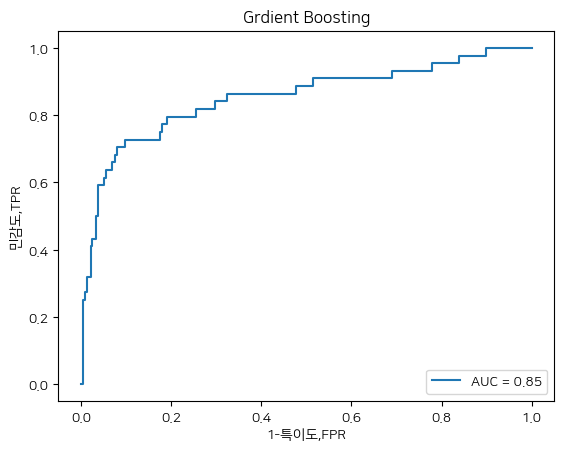

오분류율: 0.108
리프트(Lift): 4.339
인공신경망
Confusion matrix: 
[[218  17]
 [ 16  28]] 

              precision    recall  f1-score   support

           0      0.932     0.928     0.930       235
           1      0.622     0.636     0.629        44

    accuracy                          0.882       279
   macro avg      0.777     0.782     0.779       279
weighted avg      0.883     0.882     0.882       279



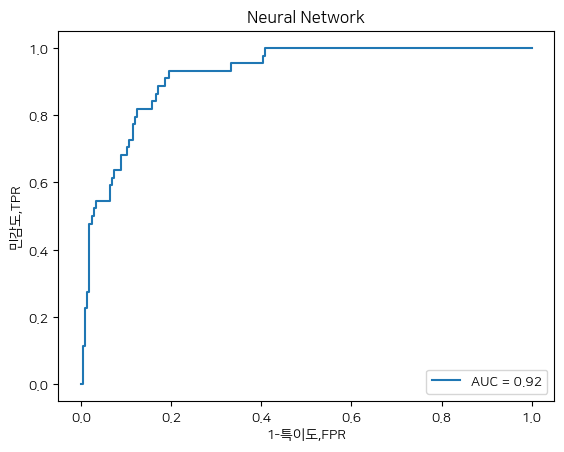

오분류율: 0.118
리프트(Lift): 3.945


In [8]:
# 데이터 불러오기
df_raw = pd.read_csv("통신고객이탈.csv")

# 결측치 확인 및 처리
df_raw.isnull().sum()
    # 결측치를 인식하지 못하여 처리
df_raw['USAGE_BAND'].replace("None", np.nan, inplace=True)
df_raw['USAGE_BAND'].fillna(df_raw['USAGE_BAND'].mode()[0], inplace=True)
    # 종속변수 처리
df_raw['CHURN'].replace({'Churned': 1, 'Active': 0}, inplace = True)
df_raw.drop(["CUSTOMER_ID"], axis =1, inplace = True)
    # 목표변수/설명변수 분리
df_raw_x = df_raw.drop("CHURN", axis = 1, inplace = False)
df_raw_y = df_raw["CHURN"] 
    # 연속형 변수 처리
df_raw_x_num = df_raw_x.select_dtypes(exclude = "object")
v_feature_names = df_raw_x_num.columns

scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_raw_x_num)
df_x_scaled = pd.DataFrame(df_x_scaled, columns=v_feature_names)
    # 범주형 변수 처리
df_raw_x_char = df_raw_x.select_dtypes(include = "object")
df_x_dummy = pd.get_dummies(df_raw_x_char)
    # 데이터 결합
df_x_raw_dummy = df_raw_x_num.join(df_x_dummy)
df_x_scale_dummy = df_x_scaled.join(df_x_dummy)
df_x_scale_raw = df_x_scaled.join(df_raw_x_char)

# 데이터 분할
df_train_x_rd, df_test_x_rd, df_train_y, df_test_y = train_test_split(df_x_raw_dummy, df_raw_y
                                    , test_size = 0.3, random_state = 1234)

df_train_x_sd, df_test_x_sd, df_train_y, df_test_y = train_test_split(df_x_scale_dummy, df_raw_y
                                    , test_size = 0.3, random_state = 1234)

df_train_x_reg, df_test_x_reg, df_train_y, df_test_y = train_test_split(df_x_scale_raw, df_raw_y
                                    , test_size = 0.3, random_state = 1234)

# 분석 모델 리스트
model = ["DecisionTree", "RandomForest", "GradientBoosting", "NeuralNet"]
train_accuracy = []; test_accuracy = []

# 의사결정나무
dt_final = DecisionTreeClassifier(max_depth=6, min_samples_split=54, min_samples_leaf=20, random_state=1234)
dt_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(dt_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(dt_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = dt_final.predict_proba(df_test_x_rd)[:, 1]
y_pred = dt_final.predict(df_test_x_rd)

print("의사결정나무")
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
print(classification_report(df_test_y, y_pred, digits=3))
print("=======================================================")

fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1)
roc_auc = auc(fpr, tpr)
plt.title("Decision Tree")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()
print("=======================================================")

# 오분류율, 향상도
conf_matrix = confusion_matrix(df_test_y, y_pred)
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]
N = conf_matrix.sum()
precision = TP / (TP + FP)
baseline_support = (TP + FN) / N
lift_score = precision / baseline_support
print("오분류율: {:.3f}".format((FP+FN)/N))
print(f"리프트(Lift): {lift_score:.3f}")
print("=======================================================")

# 랜덤포레스트
rf_final = RandomForestClassifier(min_samples_leaf=1, max_depth=16, n_estimators=110, random_state=1234)
rf_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(rf_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(rf_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = rf_final.predict_proba(df_test_x_rd)[:, 1]
y_pred = rf_final.predict(df_test_x_rd)

print("랜덤포레스트")
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
print(classification_report(df_test_y, y_pred, digits=3))
print("=======================================================")

fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1)
roc_auc = auc(fpr, tpr)
plt.title("Random Forest")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()
print("=======================================================")

# 오분류율, 향상도
conf_matrix = confusion_matrix(df_test_y, y_pred)
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]
N = conf_matrix.sum()
precision = TP / (TP + FP)
baseline_support = (TP + FN) / N
lift_score = precision / baseline_support
print("오분류율: {:.3f}".format((FP+FN)/N))
print(f"리프트(Lift): {lift_score:.3f}")
print("=======================================================")

# 그래디언트부스팅
gb_final = GradientBoostingClassifier(min_samples_leaf=5, max_depth=8, n_estimators=100,
			 learning_rate=0.8, random_state=1234)
gb_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(gb_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(gb_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = gb_final.predict_proba(df_test_x_rd)[:, 1]
y_pred = gb_final.predict(df_test_x_rd)

print("그래디언트부스팅")
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)),"\n")
print(classification_report(df_test_y, y_pred, digits=3))
print("=======================================================")

fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1)
roc_auc = auc(fpr, tpr)
plt.title("Grdient Boosting")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()
print("=======================================================")

# 오분류율, 향상도
conf_matrix = confusion_matrix(df_test_y, y_pred)
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]
N = conf_matrix.sum()
precision = TP / (TP + FP)
baseline_support = (TP + FN) / N
lift_score = precision / baseline_support
print("오분류율: {:.3f}".format((FP+FN)/N))
print(f"리프트(Lift): {lift_score:.3f}")
print("=======================================================")

# 인공신경망
nn_final = MLPClassifier(hidden_layer_sizes=(75, 75), activation="relu", solver="adam", random_state = 1234)
nn_final.fit(df_train_x_sd, df_train_y)

# 정확도
train_accuracy.append(nn_final.score(df_train_x_sd, df_train_y))
test_accuracy.append(nn_final.score(df_test_x_sd, df_test_y))

# 예측값
y_prob_1 = nn_final.predict_proba(df_test_x_sd)[:, 1]
y_pred = nn_final.predict(df_test_x_sd)

print("인공신경망")
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)),"\n")
print(classification_report(df_test_y, y_pred, digits=3))
print("=======================================================")

fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1)
roc_auc = auc(fpr, tpr)
plt.title("Neural Network")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()
print("=======================================================")
# 오분류율, 향상도
conf_matrix = confusion_matrix(df_test_y, y_pred)
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]
N = conf_matrix.sum()
precision = TP / (TP + FP)
baseline_support = (TP + FN) / N
lift_score = precision / baseline_support
print("오분류율: {:.3f}".format((FP+FN)/N))
print(f"리프트(Lift): {lift_score:.3f}")

의사결정나무, 랜덤포레스트, 그래디언트부스팅, 인공신경망의 오분류율은 0.086, 0.093, 0.108, 0.118로 의사결정나무가 가장 낮은것으로 나타났다.<br>
이는 의사결정나무와 랜덤포레스트가 그리드서치로 검색되어 정확한 값을 가졌기 때문으로 보인다.<br>
여러번 시행하는 경우 랜덤서치의 값이 달라지며, 그래디언트부스팅과 인공신경망의 오분류율이 더 낮은 경우도 있었다.<br>
향상도도 각각 5.035, 4.756, 4.339, 3.945로 의사결정나무가 가장 높은 수치를 보였으나, 랜덤서치의 변수를 고려하였을 때, 다른 방법도 우수한 성능을 보였다.